<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Kala Ariadna Guevara


# Introducción
En procesamiento digital de señales, trabajamos con señales discretas o en otras palabras, muestras en el tiempo. Para analizar su contenido en frecuencia usamos la Transformada Discreta de Fourier (DFT), representado en la ecuación 1, sin embargo, en digital utilizamos el algoritmo FFT (Fast Fourier Transform). Esta relaciona una señal finita de N muestras con una representación espectral compuesta por N coeficientes en el dominio de la frecuencia. La DFT supone que la señal analizada es periódica en ventanas de longitud N pero si la frecuencia de la señal no es múltiplo exacto de la resolución frecuencial, $$\Delta f = \frac{f_s}{N}$$ocurre un desajuste de frecuencia. Básicamente esto sería que la energía del tono no queda concentrada en un solo bin espectral, sino que se "derrame" sobre bins vecinos. Este derrame es el que denominamos derrame espectral y se observa como lóbulos secundarios alrededor del pico principal. Un cambio estético que se puede realizar es el zero padding, es estético ya que no mejora resolución real ni reduce leakage, solo interpola la DFT, permitiendo visualizar con mayor detalle dónde se ubican los picos. El zero padding consiste en agregar ceros al final de la señal antes de aplicar la DFT. Si la señal original tiene longitud N, al extenderla a M>N con ceros, la resolución en frecuencia aparente es: $$\Delta f = \frac{f_s}{M}$$ Al aumentar M, obtenemos más puntos en la grilla frecuencial y el espectro se observa más suave e interpolado.

Otro concepto explorado en este trabajo que precisa de una introducción previa es la Densidad Espectral de Potencia (PSD, siglas en inglés). Esta describe cómo se distribuye la potencia de una señal en el dominio de la frecuencia y permite comparar señales en términos de frecuencia/potencia. A partir de la DFT llegamos a la ecuación 3. Por otro lado, la suma de todos los valores de la PSD corresponde a la potencia media de la señal, que se relaciona con Parseval. La identidad de Parseval establece que la energía (o potencia media) de una señal es la misma en el dominio del tiempo que en el dominio de la frecuencia, se observa a continuación en la ecuación 3. Esta igualdad es fundamental porque valida que las representaciones en tiempo y frecuencia son consistentes y no pierden información.

En este trabajo se exige analizar el desparramo espectral a partir de la DFT a medida que se experimenta con el senoidal de frecuencia y con la potencia normalizada. A su vez, también se busca utilizar el zero padding, la densidad espectral de potencia y la identidad de Parseval para profundizar el trabajo.

#### **Ecuación 1: Definición de la DFT**
Para una señal discreta \( x[n] \) de longitud \( N \), X[k] siendo los coeficientes espectrales y x[n] la señal en el tiempo escribimos:

$$
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j \frac{2\pi}{N}kn}, \quad k = 0,1,\dots,N-1
$$

---

#### **Ecuación 2: Densidad espectral de potencia (PSD)**
Definimos la densidad espectral de potencia como:

$$
P[k] = \frac{|X[k]|^2}{N^2}
$$

donde ∣X[k]∣^2 representa la energía en el bin k.

---

#### **Ecuación 3: Identidad de Parseval**
La energía en tiempo y frecuencia se relacionan como:

$$
\sum_{n=0}^{N-1} |x[n]|^2 \;=\; \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2
$$


# Desarrollo

En esta sección se explica cómo se desarrolló el trabajo, para no ser redundante con los anteriores, se incluiría solamente lo nuevo. Primeramente, si se grafica con muchos puntos con marcador incluido se ve como una mancha, para evitar esto se coloca un punto cada step de puntos. Considerar que con zero padding se precisa un step más grande ya que se agregó 9 * N ceros. Se logró cambiarlo para los dos primeros gráficos, sin embargo, el tercero presentó una mancha de igual manera, por ende, se graficó de la manera básica. Luego, para pasar la potencia a la escala logarítmica en decibeles se utiliza 10 * np.log10(DP_P + 1e-12), donde el + 1e-12 es para que nunca se calcule log(0) que es indefinido. La función psd calcula la fft, la potencia por bin de frecuencia y lo normaliza. Luego se queda solo con las frecuencias positivas incluyendo cuando N es par, el bin de Nyquist. Además, como ahora solo tomamos la parte positiva, tenemos que multiplicar por 2 todas esas potencias.

# Código y gráficos

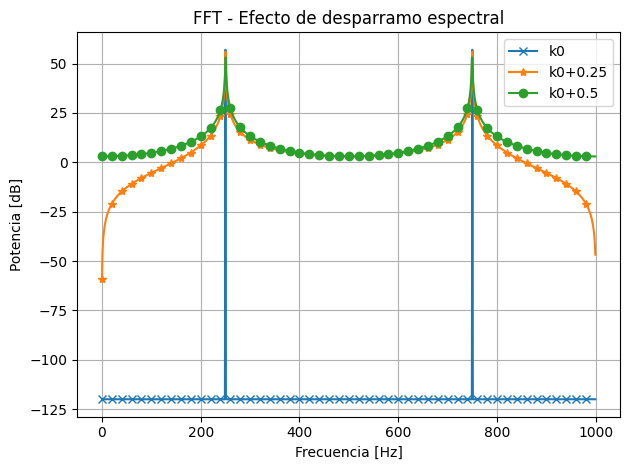

Varianzas:
k0     : 1.0
k0+0.25: 0.9989999999987679
k0+0.5 : 0.9999980125269956
Parseval verificado para k0 ✓
Parseval verificado para k0+0.25 ✓
Parseval verificado para k0+0.5 ✓


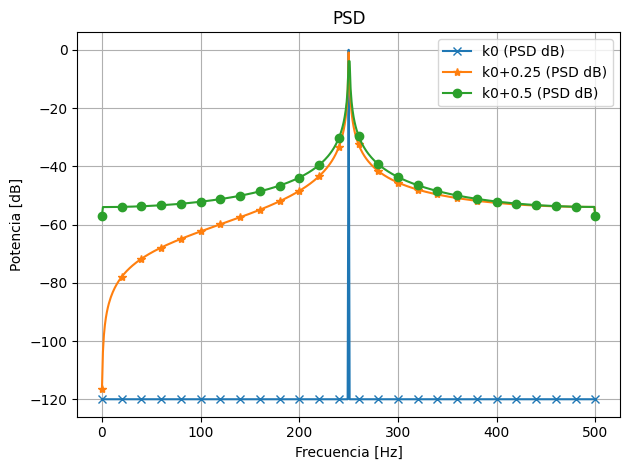

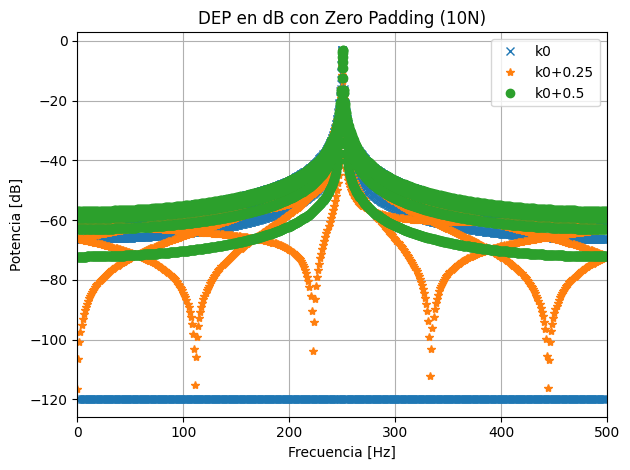

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Sep 15 12:38:43 2025

@author: gueva
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

#Definición de parámetros
N = 1000       #número de muestras
fs = N         #frecuencia de muestreo
df = fs/N      #resolución espectral
ts = 1/fs      #tiempo entre muestras

def sen(ff, nn, amp=1, dc=0, ph=0, fs=2):
    Nn = np.arange(nn)
    t = Nn/fs
    x = dc + amp * np.sin(2 * np.pi * ff * t + ph)
    return t, x

amp = np.sqrt(2)   

t1, x1 = sen(ff=(N/4)*df, nn=N, fs=fs, amp=amp)
t2, x2 = sen(ff=((N/4)+0.25)*df, nn=N, fs=fs, amp=amp)
t3, x3 = sen(ff=((N/4)+0.5)*df, nn=N, fs=fs, amp=amp)

#transformo
xx1 = fft(x1); xx1abs = np.abs(xx1)
xx2 = fft(x2); xx2abs = np.abs(xx2)
xx3 = fft(x3); xx3abs = np.abs(xx3)

#frecuencias
Ft = np.arange(N)*df

#grafico
plt.figure(1)

step = 20  # cada 20 muestras

plt.plot(Ft, 10*np.log10(xx1abs**2 + 1e-12), '-x', markevery=step, label='k0')
plt.plot(Ft, 10*np.log10(xx2abs**2 + 1e-12), '-*', markevery=step, label='k0+0.25')
plt.plot(Ft, 10*np.log10(xx3abs**2 + 1e-12), '-o', markevery=step, label='k0+0.5')

plt.title('FFT - Efecto de desparramo espectral')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#verifico varianzas
print("Varianzas:")
print("k0     :", np.var(x1))
print("k0+0.25:", np.var(x2))
print("k0+0.5 :", np.var(x3))

def psd(x):
    X = fft(x)
    # periodograma por bin (full)
    P_full = (np.abs(X)**2) / (N**2)        # P[k] tal que sum_k P[k] = mean power
    # ahora lado único (0..fs/2)
    P1 = P_full[:N//2 + 1].copy()
    if N % 2 == 0:
        P1[1:-1] = P1[1:-1] * 2            # duplicar energía de bandas positivas (excepto DC y Nyquist)
    else:
        P1[1:] = P1[1:] * 2                 # si N impar no hay bin Nyquist separado
    f1 = np.arange(0, N//2 + 1) * df
    return f1, P1, P_full, X

# computo PSDs
f1_1, P1_1, Pfull1, X1 = psd(x1)
f1_2, P1_2, Pfull2, X2 = psd(x2)
f1_3, P1_3, Pfull3, X3 = psd(x3)

tol = 1e-6  #tolerancia

signals = {
    "k0":      (x1, X1),
    "k0+0.25": (x2, X2),
    "k0+0.5":  (x3, X3),
}

for label, (x, X) in signals.items():
    pot_time = np.sum(np.abs(x)**2) #potencia en tiempo
    pot_freq = np.sum(np.abs(X)**2) / N #potencia en frecuencia
    if np.abs(pot_time - pot_freq) < tol:
        print(f"Parseval verificado para {label} ✓")
    else:
        print(f"No se cumple Parseval para {label}")

plt.figure()
step = 20

plt.plot(f1_1, 10*np.log10(P1_1 + 1e-12), '-x', markevery=step, label='k0 (PSD dB)')
plt.plot(f1_2, 10*np.log10(P1_2 + 1e-12), '-*', markevery=step, label='k0+0.25 (PSD dB)')
plt.plot(f1_3, 10*np.log10(P1_3 + 1e-12), '-o', markevery=step, label='k0+0.5 (PSD dB)')

plt.title('PSD')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#cero padding 
M = 9 * N 
df_p = fs / M 
ff_P = np.linspace(0, (M-1)*df_p, M) 

signals = [x1, x2, x3] 
labels = ["k0", "k0+0.25", "k0+0.5"] 
markers = ['x', '*', 'o'] 

plt.figure() 
plt.title('DEP en dB con Zero Padding (10N)')
 
for sig, lab, mark in zip(signals, labels, markers): 
    padding = np.zeros(M) 
    padding[:N] = sig 
    XX_P = np.fft.fft(padding) 
    DP_P = np.abs(XX_P)**2 / (N**2)
    
    plt.plot(ff_P, 10*np.log10(DP_P + 1e-12), mark, label=lab) 
    
plt.xlim(0, fs/2) 
plt.xlabel('Frecuencia [Hz]') 
plt.ylabel('Potencia [dB]') 
plt.legend() 
plt.grid() 
plt.tight_layout() 
plt.show()

# Análisis

Teniendo en cuenta el primer gráfico, en el caso k0=N/4, la senoidal coincide exactamente con un bin de la DFT y toda su energía se concentra en un único pico del espectro. Sin embargo, al introducir una pequeña desintonía (k0+0.25 o k0+0.5), la energía ya no queda confinada a un solo bin, sino que se reparte entre varios, generando un lóbulo principal alrededor de la frecuencia de la senoidal y lóbulos laterales. Este fenómeno es el que se como desparramo espectral, y ocurre porque la DFT analiza la señal como periódica dentro de la ventana de observación. Si la señal no completa un número entero de ciclos dentro de esa ventana, aparece una discontinuidad que se traduce en energía distribuida en múltiples frecuencias.

Una observación fue que el resultado de la varianza de k0 fue exactamente 1, esto se debe a que la senoidal encaja perfecto en la ventana de N muestras. Pero, en cuanto para k0+0.25 o k0+0.5, la señal no completa un número entero de ciclos en la ventana, entonces se introduce una muy chiquita diferencia en la estimación de la varianza, aunque la energía total sigue siendo la misma en promedio. Adicionalmente, está bueno saber que python tiene precisión finita, agregando a todo lo ya dicho. Como Parseval igual se cumple dentro de la tolerancia, se prueba que la potencia total en tiempo y frecuencia es consistente.

En cuanto al gráfico de PSD, cuando la frecuencia coincide con un múltiplo de df, la DFT representa perfectamente la senoidal y se puede ver claramente un pico limpio. Cuando hay desintonía de 0.25 o 0.5, la senoidal no encaja exactamente en la ventana de N y aparece lo que se llama fuga espectral, que redistribuye la energía en varios bins. Esto explica lo consultado en la consigna, de por qué señales con frecuencias muy cercanas pueden producir espectros visiblemente distintos en la DFT.

Finalmente, el zero padding concluyó en una curva más suave o interpolada con picos y lóbulos que parecen continuos, ya que hay muchos más puntos en frecuencia. También se debe notar que, cuando la frecuencia de la señal no coincide exactamente con un bin, sin padding el pico máximo aparece en el bin más cercano y no se puede ver con exactitud su ubicación. En cambio con padding, el pico se representa con mayor resolución y se puede identificar con más precisión la frecuencia real entre bins. Luego la forma del lóbulo principal y secundarios no cambian, solo se ven con más detalle. Es importante normalizar consistentemente así se conserva la potencia total, si no se hace el valor absoluto del espectro puede verse diferente.

# Conclusión y autoevaluación del aprendizaje
Este trabajo permitió comprobar de manera práctica cómo la DFT traduce una señal discreta al dominio frecuencial y qué fenómenos aparecen cuando la frecuencia de la senoidal no coincide exactamente con un múltiplo de la resolución frecuencial. En esas condiciones se verificó que la energía no queda confinada a un único bin, sino que se distribuye en forma de lóbulos, dando lugar al efecto de desparramo espectral. Por otro lado, se observó que el uso de la PSD facilita comparar y cuantificar la potencia de las señales, y la identidad de Parseval se ocupó de asegurar la consistencia entre las representaciones en el dominio del tiempo y de la frecuencia. Finalmente el uso del zero padding, si bien no mejora la resolución real, resultó útil como recurso de interpolación, ya que permitió visualizar un espectro más suave y ubicar con mayor precisión los picos entre bins, sin alterar la forma de los lóbulos principales ni secundarios.

Con respecto a mi experiencia personal resolví este tp con muchas dudas al principio, me pareció un tema confuso. De igual forma me pareció eficiente y al punto (por ser cortito) ya que me permitió indagar y preguntar. En cuanto a código, no hay muchas cosas nuevas, más que nada la transformación de señales, la fft. Considero que fue bastante teórico, que me vino bien para ponerme en tema. Adicionalmente, la inteligencia artificial fue de mucha ayuda en cuanto a redacciones, sinónimos, explicaciones de por qué los gráficos actuaban de esa manera o operadores específicos de scipy o numpy.

# Como recurse aca va mi parrafito de aprendizaje...
En clase vimos desde cero la sinc, su modulo y su fase, lo logre entender mejor. Pero creo que lo que me llevo como enseñanza es porque uso el zero padding, que es lo bueno de esto, cuando aumento la resolucion, el lobulo se angosta y lo divido en mas bins. Porque esto me sirve? porque antes el valor tenia pocos bins para elegir donde caer, ahora no, ahora tiene opciones. Esto me provoca a mi poder hacer "zoom" y ver mejor mis datos, o con mayor claridad, que es algo que uno siempre quiere tener. Basicamente "me permite ver cosas que antes no podia ver".  Cabe aclarar que este derramo espectral solo sucede cuando la frecuencia no es un multiplo exacto de la resolucion, desparramando la energia en bins vecinos. 

Otro concepto quiza nuevo, a comparacion de la otra cursada, es la relacion con la cuantizacion:
### Q  flotante vs. q entera
Los errores en la representación en coma flotante están dominados por la precisión finita de la mantisa y afectan principalmente a los bits menos significativos, que en aquellos es cuando debo redondear para arriba o para abajo. 
Sin embargo, como el error en coma flotante depende del valor de la señal (no es constante) y permite representar números muy grandes y muy pequeños, el ruido numérico que se introduce es extremadamente bajo y en la práctica no afecta los resultados.


# Biblografía
- Holton, T. (2021). Digital signal processing: Principles and applications. Cambridge University Press. https://doi.org/10.1017/9781108290050
- NumPy user guide — NumPy v2.3 Manual. (2025). Numpy.org. https://numpy.org/doc/stable/user/index.html
- Signal processing (scipy.signal) — SciPy v1.16.1 Manual. (2025). Scipy.org. https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms